In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(18249, 10)
['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', 'Mango_4046', 'Mango_4225', 'Mango_4770', 'Small Bags', 'Large Bags', 'Total Bags']


,Unnamed: 0,Date,AveragePrice,Total Volume,Mango_4046,Mango_4225,Mango_4770,Small Bags,Large Bags,Total Bags
0,0,2015-01-04,1.49,13227219.52,13418983.33,4580388.95,805821.75,820162.83,19352383.98,20172546.81
1,1,2015-01-04,3.11,10762825.24,20157351.39,7514673.05,3181790.90,2538915.58,13380759.58,15919675.16
2,2,2015-01-04,2.50,4202248.21,16648787.37,18312735.55,4041973.63,17842.51,6715614.11,6733456.62
3,3,2015-01-04,2.12,41961932.06,3933719.09,9824602.92,14913090.04,1197267.09,18700650.65,19897917.74
4,4,2015-01-04,0.88,28965383.70,11825411.59,5804958.87,12106739.17,2132507.47,670139.65,2802647.12


In [5]:
# Drop index column
df = df.drop(columns=["Unnamed: 0"])

# Convert Date properly
df["Date"] = pd.to_datetime(df["Date"])

# Sort by Date
df = df.sort_values("Date").reset_index(drop=True)

print("Date range:", df["Date"].min(), "->", df["Date"].max())
print("Duplicate full rows:", df.duplicated().sum())

# How many rows per date?
counts = df["Date"].value_counts().sort_index()

print("Unique dates:", counts.shape[0])
print("Rows per date (min/median/max):", counts.min(), counts.median(), counts.max())

counts.head()

Date range: 2015-01-04 00:00:00 -> 2018-03-25 00:00:00
Duplicate full rows: 0
Unique dates: 1177
Rows per date (min/median/max): 1 16.0 16


Date
2015-01-04    16
2015-01-05    16
2015-01-06    15
2015-01-07    16
2015-01-08    15
Name: count, dtype: int64

In [7]:
target = "AveragePrice"

feature_cols = [c for c in df.columns if c not in ["Date", target]]

agg_dict = {target: "mean"}
for c in feature_cols:
    agg_dict[c] = "sum"

ts = df.groupby("Date", as_index=False).agg(agg_dict)
ts = ts.sort_values("Date").reset_index(drop=True)

print("Time series shape:", ts.shape)
ts.head()

Time series shape: (1177, 9)


,Date,AveragePrice,Total Volume,Mango_4046,Mango_4225,Mango_4770,Small Bags,Large Bags,Total Bags
0,2015-01-04,1.775625,3.948330e+08,1.494015e+08,1.712488e+08,1.186901e+08,24990469.55,1.428071e+08,1.677976e+08
1,2015-01-05,1.551250,5.150895e+08,1.561343e+08,2.049612e+08,1.683766e+08,24252067.80,1.688620e+08,1.931141e+08
2,2015-01-06,1.772000,4.948473e+08,1.171171e+08,1.525849e+08,1.667802e+08,12611940.68,1.344473e+08,1.470593e+08
3,2015-01-07,1.931250,5.044030e+08,1.762601e+08,2.042938e+08,1.706142e+08,26530553.82,1.730899e+08,1.996205e+08
4,2015-01-08,1.800000,4.646058e+08,1.500866e+08,1.647289e+08,1.426865e+08,20461320.60,1.670942e+08,1.875556e+08


In [9]:
ts = ts.copy()

# Basic calendar features
ts["year"] = ts["Date"].dt.year
ts["month"] = ts["Date"].dt.month
ts["dayofweek"] = ts["Date"].dt.dayofweek
ts["dayofyear"] = ts["Date"].dt.dayofyear

# Cyclic encodings (VERY important for linear models)
ts["dow_sin"] = np.sin(2*np.pi*ts["dayofweek"]/7)
ts["dow_cos"] = np.cos(2*np.pi*ts["dayofweek"]/7)

ts["month_sin"] = np.sin(2*np.pi*ts["month"]/12)
ts["month_cos"] = np.cos(2*np.pi*ts["month"]/12)

ts["doy_sin"] = np.sin(2*np.pi*ts["dayofyear"]/365.25)
ts["doy_cos"] = np.cos(2*np.pi*ts["dayofyear"]/365.25)

ts.head()

,Date,AveragePrice,Total Volume,Mango_4046,Mango_4225,Mango_4770,Small Bags,Large Bags,Total Bags,year,month,dayofweek,dayofyear,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos
0,2015-01-04,1.775625,3.948330e+08,1.494015e+08,1.712488e+08,1.186901e+08,24990469.55,1.428071e+08,1.677976e+08,2015,1,6,4,-0.781831,0.623490,0.5,0.866025,0.068755,0.997634
1,2015-01-05,1.551250,5.150895e+08,1.561343e+08,2.049612e+08,1.683766e+08,24252067.80,1.688620e+08,1.931141e+08,2015,1,0,5,0.000000,1.000000,0.5,0.866025,0.085906,0.996303
2,2015-01-06,1.772000,4.948473e+08,1.171171e+08,1.525849e+08,1.667802e+08,12611940.68,1.344473e+08,1.470593e+08,2015,1,1,6,0.781831,0.623490,0.5,0.866025,0.103031,0.994678
3,2015-01-07,1.931250,5.044030e+08,1.762601e+08,2.042938e+08,1.706142e+08,26530553.82,1.730899e+08,1.996205e+08,2015,1,2,7,0.974928,-0.222521,0.5,0.866025,0.120126,0.992759
4,2015-01-08,1.800000,4.646058e+08,1.500866e+08,1.647289e+08,1.426865e+08,20461320.60,1.670942e+08,1.875556e+08,2015,1,3,8,0.433884,-0.900969,0.5,0.866025,0.137185,0.990545


In [11]:
def add_lags(df, col, lags):
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    return df

def add_rolls(df, col, windows):
    for w in windows:
        df[f"{col}_rollmean{w}"] = df[col].shift(1).rolling(w).mean()
        df[f"{col}_rollstd{w}"]  = df[col].shift(1).rolling(w).std()
    return df

PRICE_LAGS = [1,7,14,30,60]
ROLL_WINS = [7,14,30]

# Price features
ts = add_lags(ts, "AveragePrice", PRICE_LAGS)
ts = add_rolls(ts, "AveragePrice", ROLL_WINS)

# Momentum
ts["price_diff_1"] = ts["AveragePrice"].shift(1) - ts["AveragePrice"].shift(2)
ts["price_diff_7"] = ts["AveragePrice"].shift(1) - ts["AveragePrice"].shift(8)
ts["price_pctchg_1"] = ts["AveragePrice"].shift(1).pct_change(1)
ts["price_pctchg_7"] = ts["AveragePrice"].shift(1).pct_change(7)

# Volume-based lags (important but only lagged!)
volume_cols = ["Total Volume","Mango_4046","Mango_4225","Mango_4770","Small Bags","Large Bags","Total Bags"]

for col in volume_cols:
    ts = add_lags(ts, col, [1,7,14,30])
    ts = add_rolls(ts, col, [7,14,30])
    ts[f"{col}_log"] = np.log1p(ts[col])
    ts = add_lags(ts, f"{col}_log", [1,7,14,30])

ts.head(15)

C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1475359431.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{L}"] = df[col].shift(L)
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1475359431.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{L}"] = df[col].shift(L)
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1475359431.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

,Date,AveragePrice,Total Volume,Mango_4046,Mango_4225,Mango_4770,Small Bags,Large Bags,Total Bags,year,...,Total Bags_rollstd7,Total Bags_rollmean14,Total Bags_rollstd14,Total Bags_rollmean30,Total Bags_rollstd30,Total Bags_log,Total Bags_log_lag1,Total Bags_log_lag7,Total Bags_log_lag14,Total Bags_log_lag30
0,2015-01-04,1.775625,3.948330e+08,1.494015e+08,1.712488e+08,1.186901e+08,24990469.55,1.428071e+08,1.677976e+08,2015,...,NaN,NaN,NaN,NaN,NaN,18.938269,NaN,NaN,NaN,NaN
1,2015-01-05,1.551250,5.150895e+08,1.561343e+08,2.049612e+08,1.683766e+08,24252067.80,1.688620e+08,1.931141e+08,2015,...,NaN,NaN,NaN,NaN,NaN,19.078792,18.938269,NaN,NaN,NaN
2,2015-01-06,1.772000,4.948473e+08,1.171171e+08,1.525849e+08,1.667802e+08,12611940.68,1.344473e+08,1.470593e+08,2015,...,NaN,NaN,NaN,NaN,NaN,18.806346,19.078792,NaN,NaN,NaN
3,2015-01-07,1.931250,5.044030e+08,1.762601e+08,2.042938e+08,1.706142e+08,26530553.82,1.730899e+08,1.996205e+08,2015,...,NaN,NaN,NaN,NaN,NaN,19.111928,18.806346,NaN,NaN,NaN
4,2015-01-08,1.800000,4.646058e+08,1.500866e+08,1.647289e+08,1.426865e+08,20461320.60,1.670942e+08,1.875556e+08,2015,...,NaN,NaN,NaN,NaN,NaN,19.049586,19.111928,NaN,NaN,NaN
5,2015-01-09,1.823125,5.109777e+08,1.674459e+08,1.605042e+08,1.698857e+08,17471116.36,1.577539e+08,1.752250e+08,2015,...,NaN,NaN,NaN,NaN,NaN,18.981582,19.049586,NaN,NaN,NaN
6,2015-01-10,1.636667,5.672091e+08,1.684964e+08,1.633521e+08,1.287278e+08,20154364.89,1.270939e+08,1.472483e+08,2015,...,NaN,NaN,NaN,NaN,NaN,18.807631,18.981582,NaN,NaN,NaN
7,2015-01-11,1.941875,4.536581e+08,1.753992e+08,1.691844e+08,2.089315e+08,18711202.26,1.093182e+08,1.280294e+08,2015,...,2.116175e+07,NaN,NaN,NaN,NaN,18.667771,18.807631,18.938269,NaN,NaN
8,2015-01-12,1.854000,5.071543e+08,1.582902e+08,1.876070e+08,1.996340e+08,19572468.08,1.042404e+08,1.238128e+08,2015,...,2.748180e+07,NaN,NaN,NaN,NaN,18.634281,18.667771,19.078792,NaN,NaN
9,2015-01-13,1.631250,4.887437e+08,1.701714e+08,1.756422e+08,1.954419e+08,20349509.02,1.550890e+08,1.754385e+08,2015,...,2.945014e+07,NaN,NaN,NaN,NaN,18.982799,18.634281,18.806346,NaN,NaN


In [13]:
print("Shape after feature engineering:", ts.shape)
print("Top missing counts:")
print(ts.isna().sum().sort_values(ascending=False).head(15))

Shape after feature engineering: (1177, 139)
Top missing counts:
AveragePrice_lag60         60
Large Bags_lag30           30
AveragePrice_rollmean30    30
AveragePrice_rollstd30     30
Small Bags_log_lag30       30
Total Volume_lag30         30
Small Bags_rollstd30       30
Total Volume_rollmean30    30
Total Volume_rollstd30     30
Small Bags_rollmean30      30
Total Volume_log_lag30     30
Mango_4046_lag30           30
Total Bags_log_lag30       30
Mango_4046_rollmean30      30
Mango_4046_rollstd30       30
dtype: int64


In [19]:
print("Total columns in ts:", len(ts.columns))

for i, col in enumerate(ts.columns):
    print(f"{i}: {col}")

Total columns in ts: 139
0: Date
1: AveragePrice
2: Total Volume
3: Mango_4046
4: Mango_4225
5: Mango_4770
6: Small Bags
7: Large Bags
8: Total Bags
9: year
10: month
11: dayofweek
12: dayofyear
13: dow_sin
14: dow_cos
15: month_sin
16: month_cos
17: doy_sin
18: doy_cos
19: AveragePrice_lag1
20: AveragePrice_lag7
21: AveragePrice_lag14
22: AveragePrice_lag30
23: AveragePrice_lag60
24: AveragePrice_rollmean7
25: AveragePrice_rollstd7
26: AveragePrice_rollmean14
27: AveragePrice_rollstd14
28: AveragePrice_rollmean30
29: AveragePrice_rollstd30
30: price_diff_1
31: price_diff_7
32: price_pctchg_1
33: price_pctchg_7
34: Total Volume_lag1
35: Total Volume_lag7
36: Total Volume_lag14
37: Total Volume_lag30
38: Total Volume_rollmean7
39: Total Volume_rollstd7
40: Total Volume_rollmean14
41: Total Volume_rollstd14
42: Total Volume_rollmean30
43: Total Volume_rollstd30
44: Total Volume_log
45: Total Volume_log_lag1
46: Total Volume_log_lag7
47: Total Volume_log_lag14
48: Total Volume_log_lag30
4

In [21]:
# --- Short price lags ---
ts["price_lag1"] = ts["AveragePrice"].shift(1)
ts["price_lag2"] = ts["AveragePrice"].shift(2)
ts["price_lag3"] = ts["AveragePrice"].shift(3)

C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1647894819.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_lag1"] = ts["AveragePrice"].shift(1)
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1647894819.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_lag2"] = ts["AveragePrice"].shift(2)
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\1647894819.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

In [23]:
# --- Rolling averages (shift first to prevent leakage) ---
ts["price_rollmean5"] = ts["AveragePrice"].shift(1).rolling(5).mean()
ts["price_rollmean10"] = ts["AveragePrice"].shift(1).rolling(10).mean()
ts["price_rollmean30"] = ts["AveragePrice"].shift(1).rolling(30).mean()

C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\2401479148.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_rollmean5"] = ts["AveragePrice"].shift(1).rolling(5).mean()
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\2401479148.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_rollmean10"] = ts["AveragePrice"].shift(1).rolling(10).mean()
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\2401479148.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

In [25]:
# --- Same week previous year ---
ts["price_lag365"] = ts["AveragePrice"].shift(365)

ts["price_lastyear_week_avg"] = (
    ts["AveragePrice"]
    .shift(365)
    .rolling(7)
    .mean()
)

C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\2933690873.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_lag365"] = ts["AveragePrice"].shift(365)
C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\2933690873.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_lastyear_week_avg"] = (


In [27]:
# --- Same month previous year (±15 days) ---
ts["price_lastyear_month_avg"] = (
    ts["AveragePrice"]
    .shift(365)
    .rolling(30)
    .mean()
)

C:\Users\amuel\AppData\Local\Temp\ipykernel_18736\602570407.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ts["price_lastyear_month_avg"] = (


In [29]:
print("New shape:", ts.shape)
print(ts[[
    "price_lag1",
    "price_lag2",
    "price_lag3",
    "price_rollmean5",
    "price_rollmean10",
    "price_rollmean30",
    "price_lastyear_week_avg",
    "price_lastyear_month_avg"
]].head(20))

print("\nMissing counts:")
print(ts[[
    "price_lag1",
    "price_rollmean30",
    "price_lastyear_week_avg",
    "price_lastyear_month_avg"
]].isna().sum())

New shape: (1177, 148)
    price_lag1  price_lag2  price_lag3  price_rollmean5  price_rollmean10  \
0          NaN         NaN         NaN              NaN               NaN   
1     1.775625         NaN         NaN              NaN               NaN   
2     1.551250    1.775625         NaN              NaN               NaN   
3     1.772000    1.551250    1.775625              NaN               NaN   
4     1.931250    1.772000    1.551250              NaN               NaN   
5     1.800000    1.931250    1.772000         1.766025               NaN   
6     1.823125    1.800000    1.931250         1.775525               NaN   
7     1.636667    1.823125    1.800000         1.792608               NaN   
8     1.941875    1.636667    1.823125         1.826583               NaN   
9     1.854000    1.941875    1.636667         1.811133               NaN   
10    1.631250    1.854000    1.941875         1.777383          1.771704   
11    1.809333    1.631250    1.854000         1.7746

In [41]:
API_KEY = 'b2172c9a53a74592bd270741262202'
base = 'http://api.weatherapi.com/v1'

In [37]:
import os
import pandas as pd
import numpy as np

CACHE_PATH = "weather_cache_india_mexico.csv"

# Load existing cache if present, FORCE parse Date
if os.path.exists(CACHE_PATH):
    weather_cache = pd.read_csv(CACHE_PATH)
else:
    weather_cache = pd.DataFrame(columns=["Date", "country"])

# Force correct dtypes
if "Date" in weather_cache.columns:
    weather_cache["Date"] = pd.to_datetime(weather_cache["Date"], errors="coerce")
if "country" in weather_cache.columns:
    weather_cache["country"] = weather_cache["country"].astype(str)

# Drop any bad cached rows
weather_cache = weather_cache.dropna(subset=["Date"])

# Build existing keys safely
existing_keys = set(zip(weather_cache["Date"].dt.date, weather_cache["country"]))

print("Cache currently has rows:", len(weather_cache))
list(weather_cache.columns), weather_cache.head()

Cache currently has rows: 0


(['Date', 'country'],
 Empty DataFrame
 Columns: [Date, country]
 Index: [])

In [43]:
import time
import requests
import pandas as pd
import numpy as np

LOCATIONS = {
    "india": "16.99,73.31",   # Ratnagiri
    "mexico": "14.90,-92.27"  # Tapachula
}

def fetch_weatherapi_day(api_key: str, q: str, dt: str) -> dict:
    url = "http://api.weatherapi.com/v1/history.json"
    params = {"key": api_key, "q": q, "dt": dt}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    day = data["forecast"]["forecastday"][0]["day"]
    return {
        "avgtemp_c": day.get("avgtemp_c"),
        "maxtemp_c": day.get("maxtemp_c"),
        "mintemp_c": day.get("mintemp_c"),
        "totalprecip_mm": day.get("totalprecip_mm"),
        "avghumidity": day.get("avghumidity"),
        "maxwind_kph": day.get("maxwind_kph"),
    }

dates = pd.to_datetime(ts["Date"]).dt.date.unique()
dates = sorted(dates)

rows = []
calls = 0

for d in dates:
    dt_str = pd.Timestamp(d).strftime("%Y-%m-%d")
    for country, q in LOCATIONS.items():
        key = (d, country)
        if key in existing_keys:
            continue

        w = fetch_weatherapi_day(API_KEY, q=q, dt=dt_str)
        rows.append({"Date": pd.Timestamp(d), "country": country, **w})

        calls += 1
        if calls % 25 == 0:
            print("API calls made:", calls, "| last date:", dt_str, "| country:", country)

        time.sleep(0.25)

        if calls % 20 == 0:
            new_df = pd.DataFrame(rows)
            weather_cache = pd.concat([weather_cache, new_df], ignore_index=True)
            weather_cache.to_csv(CACHE_PATH, index=False)
            existing_keys = set(zip(pd.to_datetime(weather_cache["Date"]).dt.date, weather_cache["country"]))
            rows = []
            print(f"Saved progress after {calls} API calls...")

# Final save
if rows:
    new_df = pd.DataFrame(rows)
    weather_cache = pd.concat([weather_cache, new_df], ignore_index=True)

weather_cache["Date"] = pd.to_datetime(weather_cache["Date"], errors="coerce")
weather_cache = weather_cache.dropna(subset=["Date"])
weather_cache.to_csv(CACHE_PATH, index=False)

print("Weather cache shape:", weather_cache.shape)
weather_cache.head()

Saved progress after 20 API calls...
API calls made: 25 | last date: 2015-01-16 | country: india
Saved progress after 40 API calls...
API calls made: 50 | last date: 2015-01-28 | country: mexico
Saved progress after 60 API calls...
API calls made: 75 | last date: 2015-02-10 | country: india
Saved progress after 80 API calls...
API calls made: 100 | last date: 2015-02-22 | country: mexico
Saved progress after 100 API calls...
Saved progress after 120 API calls...
API calls made: 125 | last date: 2015-03-07 | country: india
Saved progress after 140 API calls...
API calls made: 150 | last date: 2015-03-19 | country: mexico
Saved progress after 160 API calls...
API calls made: 175 | last date: 2015-04-01 | country: india
Saved progress after 180 API calls...
API calls made: 200 | last date: 2015-04-13 | country: mexico
Saved progress after 200 API calls...
Saved progress after 220 API calls...
API calls made: 225 | last date: 2015-04-26 | country: india
Saved progress after 240 API calls..

,Date,country,avgtemp_c,maxtemp_c,mintemp_c,totalprecip_mm,avghumidity,maxwind_kph
0,2015-01-04,india,24.3,28.4,20.4,0.0,62.0,14.8
1,2015-01-04,mexico,27.0,32.4,23.4,0.0,57.0,11.9
2,2015-01-05,india,26.3,30.8,22.4,0.0,58.0,19.4
3,2015-01-05,mexico,26.7,32.1,22.1,0.0,59.0,16.9
4,2015-01-06,india,25.6,30.4,22.2,0.0,63.0,16.3


In [45]:
weather_cache = pd.read_csv("weather_cache_india_mexico.csv")
weather_cache["Date"] = pd.to_datetime(weather_cache["Date"])

weather_wide = weather_cache.pivot_table(
    index="Date",
    columns="country",
    aggfunc="mean"
)

# Flatten multi-index columns
weather_wide.columns = [f"{country}_{metric}" for metric, country in weather_wide.columns]
weather_wide = weather_wide.reset_index()

print("Weather wide shape:", weather_wide.shape)
weather_wide.head()

Weather wide shape: (1177, 13)


,Date,india_avghumidity,mexico_avghumidity,india_avgtemp_c,mexico_avgtemp_c,india_maxtemp_c,mexico_maxtemp_c,india_maxwind_kph,mexico_maxwind_kph,india_mintemp_c,mexico_mintemp_c,india_totalprecip_mm,mexico_totalprecip_mm
0,2015-01-04,62.0,57.0,24.3,27.0,28.4,32.4,14.8,11.9,20.4,23.4,0.0,0.0
1,2015-01-05,58.0,59.0,26.3,26.7,30.8,32.1,19.4,16.9,22.4,22.1,0.0,0.0
2,2015-01-06,63.0,61.0,25.6,26.5,30.4,31.4,16.3,12.2,22.2,23.0,0.0,0.0
3,2015-01-07,62.0,57.0,24.7,26.2,29.0,31.9,16.2,15.5,21.5,22.1,0.0,0.0
4,2015-01-08,59.0,58.0,24.3,26.0,29.9,31.4,13.3,16.6,20.1,22.5,0.0,0.0


In [47]:
ts = ts.merge(weather_wide, on="Date", how="left")

print("ts shape after weather merge:", ts.shape)
ts.filter(regex="india_|mexico_").head()

ts shape after weather merge: (1177, 160)


,india_avghumidity,mexico_avghumidity,india_avgtemp_c,mexico_avgtemp_c,india_maxtemp_c,mexico_maxtemp_c,india_maxwind_kph,mexico_maxwind_kph,india_mintemp_c,mexico_mintemp_c,india_totalprecip_mm,mexico_totalprecip_mm
0,62.0,57.0,24.3,27.0,28.4,32.4,14.8,11.9,20.4,23.4,0.0,0.0
1,58.0,59.0,26.3,26.7,30.8,32.1,19.4,16.9,22.4,22.1,0.0,0.0
2,63.0,61.0,25.6,26.5,30.4,31.4,16.3,12.2,22.2,23.0,0.0,0.0
3,62.0,57.0,24.7,26.2,29.0,31.9,16.2,15.5,21.5,22.1,0.0,0.0
4,59.0,58.0,24.3,26.0,29.9,31.4,13.3,16.6,20.1,22.5,0.0,0.0


In [49]:
weather_cols = [c for c in ts.columns if c.startswith("india_") or c.startswith("mexico_")]

print("Weather metric columns:", len(weather_cols))

# Short lags
for col in weather_cols:
    for L in [1,2,3]:
        ts[f"{col}_lag{L}"] = ts[col].shift(L)

# Rolling averages (shift first)
for col in weather_cols:
    ts[f"{col}_roll5"]  = ts[col].shift(1).rolling(5).mean()
    ts[f"{col}_roll10"] = ts[col].shift(1).rolling(10).mean()
    ts[f"{col}_roll30"] = ts[col].shift(1).rolling(30).mean()

print("Weather lag features added.")

Weather metric columns: 12
Weather lag features added.


In [51]:
print("Total columns now:", len(ts.columns))
print("Missing values summary (top 10):")
print(ts.isna().sum().sort_values(ascending=False).head(10))

Total columns now: 232
Missing values summary (top 10):
price_lastyear_month_avg    394
price_lastyear_week_avg     371
price_lag365                365
AveragePrice_lag60           60
AveragePrice_rollstd30       30
Large Bags_rollstd30         30
Large Bags_rollmean30        30
Mango_4225_lag30             30
Large Bags_lag30             30
Mango_4225_log_lag30         30
dtype: int64


In [53]:
# Drop all rows with NaNs (caused by lags)
model_df = ts.dropna().reset_index(drop=True)

print("Final modeling rows:", len(model_df))

# Raw same-day volume columns (leakage)
leak_volume_cols = [
    "Total Volume",
    "Mango_4046",
    "Mango_4225",
    "Mango_4770",
    "Small Bags",
    "Large Bags",
    "Total Bags"
]

# Raw same-day weather columns (leakage)
leak_weather_cols = [
    c for c in model_df.columns
    if (c.startswith("india_") or c.startswith("mexico_"))
    and not ("_lag" in c or "_roll" in c)
]

print("Raw weather columns to drop:", len(leak_weather_cols))

# Define target
y = model_df["AveragePrice"]

# Drop leakage + target + date
X = model_df.drop(columns=["AveragePrice", "Date"] + leak_volume_cols + leak_weather_cols)

print("Final X shape:", X.shape)

Final modeling rows: 783
Raw weather columns to drop: 12
Final X shape: (783, 211)


In [55]:
# Variance check
low_var = X.var().sort_values().head(20)
print("Lowest variance features:")
print(low_var)

Lowest variance features:
price_lastyear_month_avg    0.000758
AveragePrice_rollstd30      0.000801
AveragePrice_rollmean30     0.001107
price_rollmean30            0.001107
AveragePrice_rollstd14      0.001625
AveragePrice_rollmean14     0.002599
AveragePrice_rollstd7       0.003205
price_rollmean10            0.003531
AveragePrice_rollmean7      0.005084
price_lastyear_week_avg     0.005156
price_rollmean5             0.007276
Total Bags_log_lag14        0.020139
Total Bags_log_lag7         0.020429
Total Bags_log_lag30        0.020447
Total Bags_log_lag1         0.020522
Total Volume_log_lag30      0.022064
Total Volume_log_lag7       0.022082
Total Volume_log_lag1       0.022087
Total Volume_log_lag14      0.022277
Small Bags_log_lag30        0.023352
dtype: float64


In [57]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-5)
X_var = selector.fit_transform(X)

print("Shape after variance filter:", X_var.shape)

Shape after variance filter: (783, 211)


In [59]:
import pandas as pd
import numpy as np

corr_with_price = X.copy()
corr_with_price["AveragePrice"] = y

corr = corr_with_price.corr()["AveragePrice"].drop("AveragePrice")

# Absolute correlation ranking
corr_sorted = corr.abs().sort_values(ascending=False)

print("Top 20 most correlated with price:")
print(corr_sorted.head(20))

Top 20 most correlated with price:
Mango_4770_log             0.166707
mexico_mintemp_c_lag2      0.130894
Mango_4225_log             0.121087
Total Volume_log           0.116412
Small Bags_log             0.113289
mexico_avgtemp_c_lag2      0.102135
mexico_avgtemp_c_roll30    0.100677
mexico_mintemp_c_roll30    0.100144
india_mintemp_c_lag3       0.098013
mexico_mintemp_c_roll5     0.097844
india_mintemp_c_roll10     0.091150
india_avgtemp_c_roll10     0.090841
mexico_avgtemp_c_lag3      0.089872
mexico_avgtemp_c_roll5     0.089771
india_avgtemp_c_lag3       0.089259
india_mintemp_c_roll5      0.088794
india_avgtemp_c_roll5      0.087651
mexico_mintemp_c_lag1      0.086504
Small Bags_lag1            0.086036
doy_cos                    0.084926
Name: AveragePrice, dtype: float64


In [61]:
# Correlation matrix (can be heavy)
corr_matrix = X.corr().abs()

# Find highly correlated feature pairs
high_corr_pairs = []

threshold = 0.95

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            high_corr_pairs.append((col_i, col_j, corr_matrix.iloc[i, j]))

print("Number of feature pairs above 0.95 correlation:", len(high_corr_pairs))
print("Sample of high-correlation pairs:")
print(high_corr_pairs[:10])

Number of feature pairs above 0.95 correlation: 73
Sample of high-correlation pairs:
[('dayofyear', 'month', 0.9966161082566731), ('doy_sin', 'month_sin', 0.9579858503289724), ('doy_cos', 'month_cos', 0.9509910486168087), ('price_pctchg_1', 'price_diff_1', 0.9901607116123557), ('price_pctchg_7', 'price_diff_7', 0.9910625008819178), ('Total Volume_log_lag1', 'Total Volume_lag1', 0.99241625347339), ('Total Volume_log_lag7', 'Total Volume_lag7', 0.9924070145081132), ('Total Volume_log_lag14', 'Total Volume_lag14', 0.9924353893212425), ('Total Volume_log_lag30', 'Total Volume_lag30', 0.992488909263425), ('Mango_4046_log_lag1', 'Mango_4046_lag1', 0.9929308266614556)]


In [63]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

print("Top 20 RF feature importances:")
print(top_features)

Top 20 RF feature importances:
Mango_4770_log               0.014450
Mango_4046_log               0.013308
Mango_4225_log               0.012747
Mango_4770_rollmean14        0.012247
Total Bags_log               0.011825
mexico_maxwind_kph_roll30    0.011384
Large Bags_log               0.011307
AveragePrice_lag60           0.011119
Mango_4770_rollstd14         0.010975
Small Bags_log               0.010843
Small Bags_lag1              0.010647
AveragePrice_lag7            0.010530
Small Bags_log_lag1          0.010455
Total Volume_log             0.010300
mexico_mintemp_c_lag2        0.009509
Total Volume_rollmean30      0.009382
AveragePrice_lag14           0.009378
Total Volume_log_lag14       0.008380
Mango_4770_rollmean7         0.008375
AveragePrice_lag30           0.008187
dtype: float64


In [65]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)

explained = np.cumsum(pca.explained_variance_ratio_)

print("Components needed for 90% variance:",
      np.argmax(explained >= 0.90) + 1)

print("Components needed for 95% variance:",
      np.argmax(explained >= 0.95) + 1)

Components needed for 90% variance: 18
Components needed for 95% variance: 21


In [67]:
# Identify duplicate log vs raw lag pairs
dup_pairs = [
    pair for pair in high_corr_pairs
    if "_log_lag" in pair[0] or "_log_lag" in pair[1]
]

len(dup_pairs)

40

In [71]:
import re

X_pruned = X.copy()

cols = X_pruned.columns.tolist()

drop_cols = []

for col in cols:
    # look for raw lag columns (not log)
    if re.search(r"_lag\d+$", col) and "_log_" not in col:
        log_version = col.replace("_lag", "_log_lag")
        if log_version in cols:
            drop_cols.append(col)

print("Dropping raw lag columns:", len(drop_cols))

X_pruned = X_pruned.drop(columns=drop_cols)

print("Shape after dropping raw lag duplicates:", X_pruned.shape)

Dropping raw lag columns: 28
Shape after dropping raw lag duplicates: (783, 183)


In [73]:
pctchg_cols = [c for c in X_pruned.columns if "pctchg" in c]

print("Dropping pctchg columns:", len(pctchg_cols))

X_pruned = X_pruned.drop(columns=pctchg_cols)

print("Shape after dropping pctchg:", X_pruned.shape)

Dropping pctchg columns: 2
Shape after dropping pctchg: (783, 181)


In [75]:
calendar_drop = [c for c in ["month", "dayofyear"] if c in X_pruned.columns]

print("Dropping calendar cols:", calendar_drop)

X_pruned = X_pruned.drop(columns=calendar_drop)

print("Shape after calendar cleanup:", X_pruned.shape)

Dropping calendar cols: ['month', 'dayofyear']
Shape after calendar cleanup: (783, 179)


In [77]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_pruned)

explained = np.cumsum(pca.explained_variance_ratio_)

print("Components for 90% variance:",
      np.argmax(explained >= 0.90) + 1)

print("Components for 95% variance:",
      np.argmax(explained >= 0.95) + 1)

Components for 90% variance: 12
Components for 95% variance: 16


In [79]:
corr_matrix = X_pruned.corr().abs()

high_corr_pairs_pruned = []

threshold = 0.95

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            high_corr_pairs_pruned.append((col_i, col_j))

print("High correlation pairs (>0.95):",
      len(high_corr_pairs_pruned))

High correlation pairs (>0.95): 30


In [81]:
from sklearn.model_selection import train_test_split

split_index = int(len(X_pruned) * 0.8)

X_train = X_pruned.iloc[:split_index]
X_test  = X_pruned.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (626, 179)
Test size: (157, 179)


In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [85]:
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models = {
    "Linear": LinearRegression(),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5),
    "ElasticNet": ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9,1],
                               alphas=np.logspace(-3,3,50),
                               cv=5,
                               max_iter=5000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

pd.DataFrame(results).T

C:\Users\amuel\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003735489123661395, tolerance: 0.001923778787286538
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\amuel\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0057916342124624265, tolerance: 0.001923778787286538
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\amuel\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.016633527184378494, tolerance: 0.001923778787286538
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\amuel\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate

,RMSE,MAE,R2
Linear,0.366701,0.303914,-1.738625
Ridge,0.229826,0.179812,-0.075739
ElasticNet,0.223729,0.173076,-0.019422


In [87]:
# Naive prediction: yesterday's price
naive_preds = y_test.shift(1)

# drop first NaN
mask = ~naive_preds.isna()

rmse_naive = np.sqrt(mean_squared_error(y_test[mask], naive_preds[mask]))
mae_naive = mean_absolute_error(y_test[mask], naive_preds[mask])
r2_naive = r2_score(y_test[mask], naive_preds[mask])

print("Naive baseline:")
print("RMSE:", rmse_naive)
print("MAE:", mae_naive)
print("R2:", r2_naive)

Naive baseline:
RMSE: 0.28983298114992145
MAE: 0.22935149572649577
R2: -0.7045811717911845


In [89]:
improvement_rmse = (rmse_naive - 0.223729) / rmse_naive * 100
improvement_mae = (mae_naive - 0.173076) / mae_naive * 100

print("RMSE improvement vs naive: {:.2f}%".format(improvement_rmse))
print("MAE improvement vs naive: {:.2f}%".format(improvement_mae))

RMSE improvement vs naive: 22.81%
MAE improvement vs naive: 24.54%


In [93]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Identify weather columns
weather_feature_cols = [
    c for c in X_pruned.columns
    if c.startswith("india_") or c.startswith("mexico_")
]

# Drop weather
X_no_weather = X_pruned.drop(columns=weather_feature_cols)

# Split
X_train_nw = X_no_weather.iloc[:split_index]
X_test_nw  = X_no_weather.iloc[split_index:]

# Scale
scaler_nw = StandardScaler()
X_train_nw = scaler_nw.fit_transform(X_train_nw)
X_test_nw  = scaler_nw.transform(X_test_nw)

# Train
model_nw = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,1],
    alphas=np.logspace(-3,3,50),
    cv=5,
    max_iter=5000
)

model_nw.fit(X_train_nw, y_train)
preds_nw = model_nw.predict(X_test_nw)

# Metrics
rmse_nw = np.sqrt(mean_squared_error(y_test, preds_nw))
mae_nw  = mean_absolute_error(y_test, preds_nw)

print("No-weather RMSE:", rmse_nw)
print("No-weather MAE:", mae_nw)

No-weather RMSE: 0.22396895541992798
No-weather MAE: 0.1741470957096235


In [95]:
# with weather
rmse_with = 0.223729
mae_with  = 0.173076

print("RMSE improvement vs no-weather: {:.2f}%".format(
    (rmse_nw - rmse_with) / rmse_nw * 100
))

print("MAE improvement vs no-weather: {:.2f}%".format(
    (mae_nw - mae_with) / mae_nw * 100
))

RMSE improvement vs no-weather: 0.11%
MAE improvement vs no-weather: 0.62%


In [97]:
# WITH weather predictions (recompute to be safe)
model_with = models["ElasticNet"]
preds_with = model_with.predict(X_test_scaled)

errors_with = np.abs(y_test - preds_with)
errors_without = np.abs(y_test - preds_nw)

diff = errors_without - errors_with

print("Mean error improvement:", diff.mean())
print("Days weather helped:", (diff > 0).sum())
print("Days weather hurt:", (diff < 0).sum())

Mean error improvement: 0.001071267692142596
Days weather helped: 86
Days weather hurt: 71


In [99]:
coef_series = pd.Series(
    models["ElasticNet"].coef_,
    index=X_pruned.columns
)

weather_coefs = coef_series[
    coef_series.index.str.startswith("india_") |
    coef_series.index.str.startswith("mexico_")
]

weather_coefs = weather_coefs[weather_coefs != 0]

print("Non-zero weather features selected:", len(weather_coefs))
print(weather_coefs.sort_values(key=np.abs, ascending=False).head(10))

Non-zero weather features selected: 1
mexico_mintemp_c_lag2   -0.009848
dtype: float64


In [101]:
# Identify price-related features
price_feature_cols = [
    c for c in X_pruned.columns
    if c.startswith("price_") or c.startswith("AveragePrice_lag")
]

# Add seasonal features
seasonal_cols = [
    c for c in X_pruned.columns
    if "sin" in c or "cos" in c or c in ["year", "dayofweek"]
]

price_only_cols = list(set(price_feature_cols + seasonal_cols))

X_price_only = X_pruned[price_only_cols]

print("Price-only feature count:", X_price_only.shape[1])

Price-only feature count: 24


In [103]:
# Split
X_train_p = X_price_only.iloc[:split_index]
X_test_p  = X_price_only.iloc[split_index:]

# Scale
scaler_p = StandardScaler()
X_train_p = scaler_p.fit_transform(X_train_p)
X_test_p  = scaler_p.transform(X_test_p)

# Train
model_price_only = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,1],
    alphas=np.logspace(-3,3,50),
    cv=5,
    max_iter=5000
)

model_price_only.fit(X_train_p, y_train)
preds_p = model_price_only.predict(X_test_p)

# Metrics
rmse_p = np.sqrt(mean_squared_error(y_test, preds_p))
mae_p  = mean_absolute_error(y_test, preds_p)

print("Price-only RMSE:", rmse_p)
print("Price-only MAE:", mae_p)

Price-only RMSE: 0.22373970462657725
Price-only MAE: 0.17423884460023203


In [105]:
print("\nMODEL COMPARISON")
print("----------------------------")
print("Naive RMSE:", rmse_naive)
print("Price-only RMSE:", rmse_p)
print("Full model RMSE:", 0.223729)


MODEL COMPARISON
----------------------------
Naive RMSE: 0.28983298114992145
Price-only RMSE: 0.22373970462657725
Full model RMSE: 0.223729


In [107]:
# last available row
latest_features = X_price_only.iloc[[-1]]

# scale
latest_scaled = scaler_p.transform(latest_features)

# predict next day price
next_day_prediction = model_price_only.predict(latest_scaled)

print("Predicted next-day price:", next_day_prediction[0])

Predicted next-day price: 1.8336833732694355


In [127]:
# Create increase column (1 if price increased from previous day)
ts["increase"] = (ts["AveragePrice"].diff() > 0).astype(int)

# Drop first row (NaN diff)
ts = ts.iloc[1:].reset_index(drop=True)

ts[["AveragePrice", "increase"]].head()

,AveragePrice,increase
0,1.551250,0
1,1.772000,1
2,1.931250,1
3,1.800000,0
4,1.823125,1


In [129]:
# Drop rows with NaNs again (because we shifted target)
model_df_class = ts.dropna().reset_index(drop=True)

# Build X using same pruned columns
X_class = model_df_class[X_pruned.columns]

y_class = model_df_class["increase"]

print("Classification dataset shape:", X_class.shape)

Classification dataset shape: (783, 179)


In [131]:
split_index_class = int(len(X_class) * 0.8)

X_train_c = X_class.iloc[:split_index_class]
X_test_c  = X_class.iloc[split_index_class:]

y_train_c = y_class.iloc[:split_index_class]
y_test_c  = y_class.iloc[split_index_class:]

In [133]:
from sklearn.preprocessing import StandardScaler

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c  = scaler_c.transform(X_test_c)

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_log = LogisticRegression(max_iter=5000)

model_log.fit(X_train_c, y_train_c)

preds_c = model_log.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, preds_c))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, preds_c))

print("\nClassification Report:")
print(classification_report(y_test_c, preds_c))

Accuracy: 0.6815286624203821

Confusion Matrix:
[[59 19]
 [31 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.70        78
           1       0.72      0.61      0.66        79

    accuracy                           0.68       157
   macro avg       0.69      0.68      0.68       157
weighted avg       0.69      0.68      0.68       157



In [137]:
naive_preds = y_test_c.shift(1).fillna(0)

print("Naive Accuracy:", accuracy_score(y_test_c, naive_preds))

Naive Accuracy: 0.3248407643312102


Mean daily return: 0.007273409185632668
Sharpe ratio: 7.845241359749092


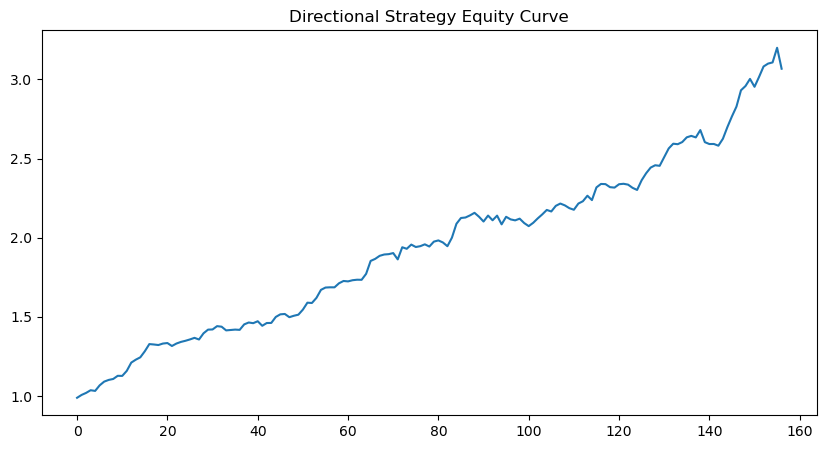

In [141]:
import numpy as np

# Long if predict up, short if predict down
#positions = np.where(preds_c == 1, 1, -1)
positions = np.where(preds_c == 1, 0.1, -0.1)

# Actual daily returns
actual_returns = model_df_class["AveragePrice"].pct_change().iloc[split_index_class:].values

# Strategy returns
strategy_returns = positions * actual_returns

# Remove first NaN if exists
strategy_returns = strategy_returns[~np.isnan(strategy_returns)]

# Cumulative performance
cumulative = np.cumprod(1 + strategy_returns)

# Sharpe ratio
sharpe = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252)

print("Mean daily return:", np.mean(strategy_returns))
print("Sharpe ratio:", sharpe)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(cumulative)
plt.title("Directional Strategy Equity Curve")
plt.show()

===== DIRECTION MODEL (Tomorrow) =====
Accuracy: 0.5095541401273885
Confusion Matrix:
 [[29 49]
 [28 51]]

Report:
               precision    recall  f1-score   support

           0       0.51      0.37      0.43        78
           1       0.51      0.65      0.57        79

    accuracy                           0.51       157
   macro avg       0.51      0.51      0.50       157
weighted avg       0.51      0.51      0.50       157


===== QUANT BACKTEST SUMMARY (Net) =====
Days: 156
Final Equity (gross): $11,333.15
Final Equity (net)  : $11,242.66
Mean daily return (net): 0.00097
Daily vol (net)        : 0.02105
Sharpe (net, ~252d)     : 0.73
Win rate                : 51.28%
Max drawdown (net)      : -15.76%
Avg turnover            : 0.073
Avg daily cost          : 0.00005
Avg abs exposure        : 0.129
% days in market         : 100.00%


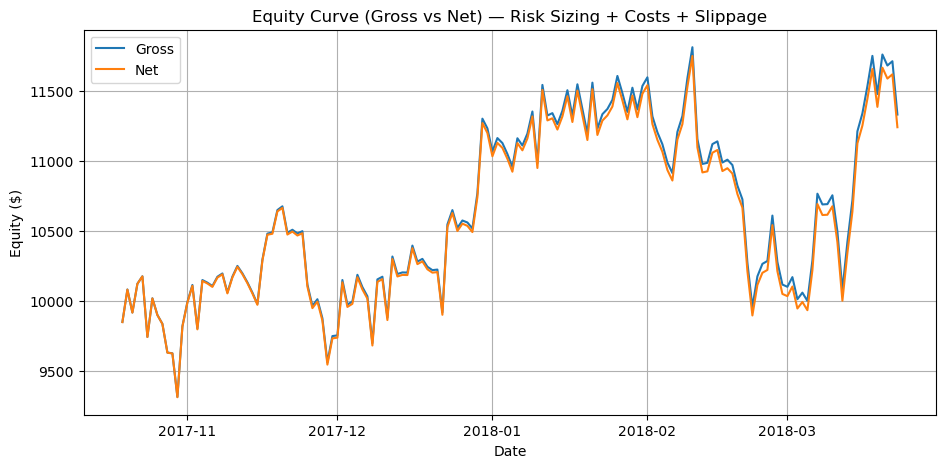

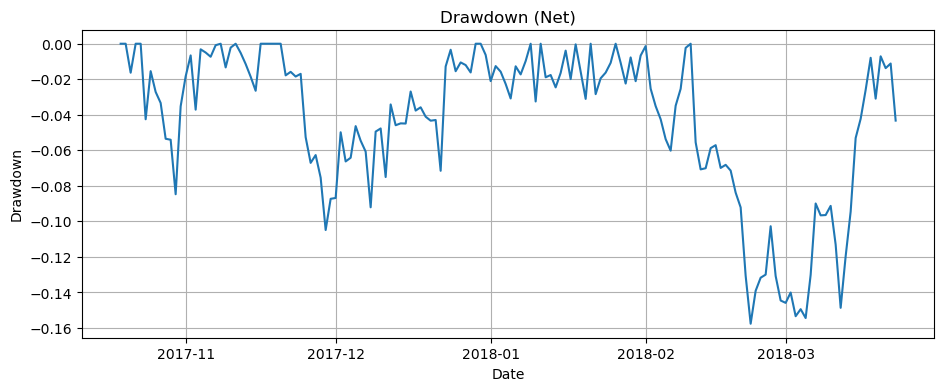

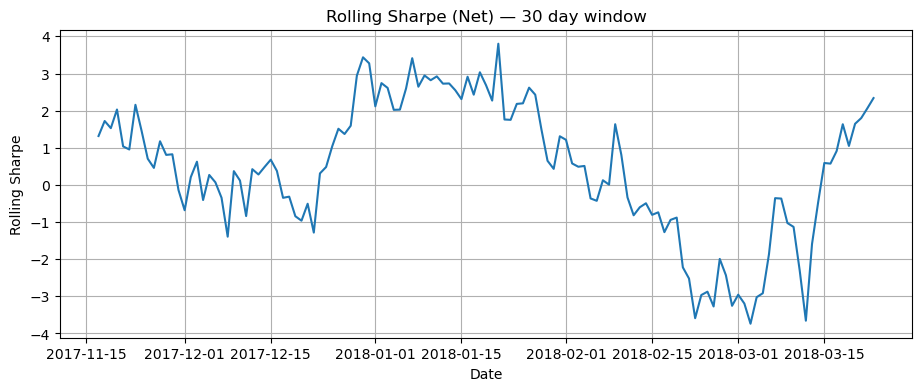

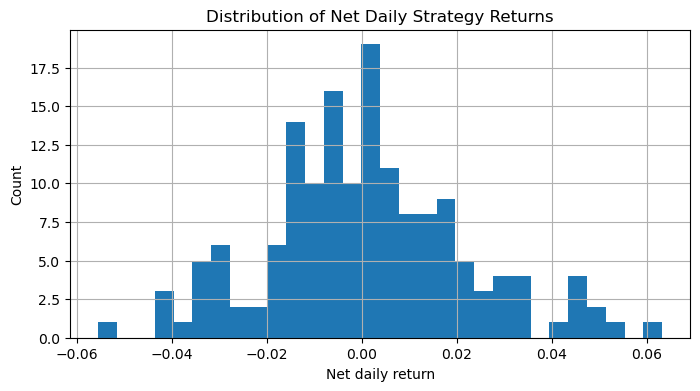

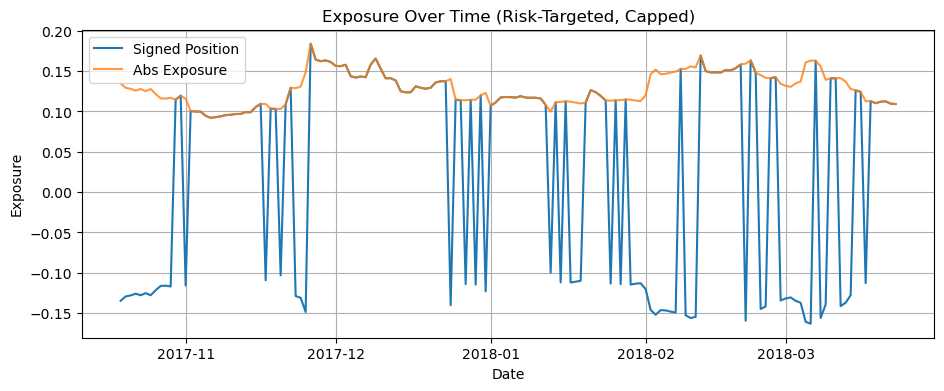

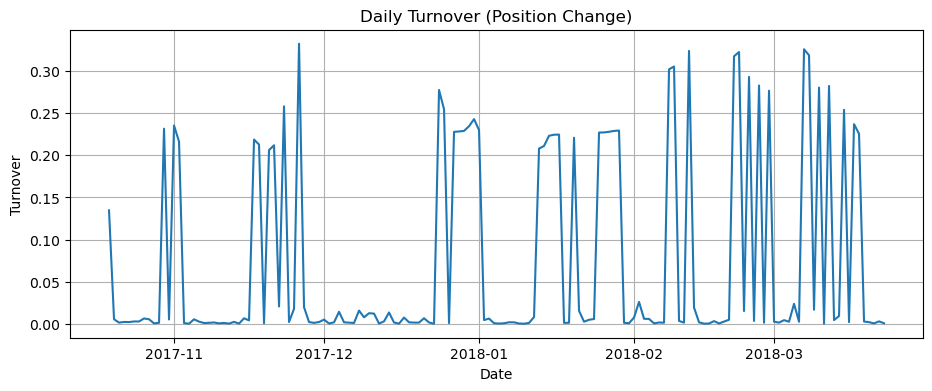

In [155]:
# =========================
# Quantitative Trading Backtest Strategy
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = model_df_class.copy().sort_values("Date").reset_index(drop=True)
# tomorrow move. compare price[t+1] vs price[t]
df["increase_tomorrow"] = (df["AveragePrice"].shift(-1) > df["AveragePrice"]).astype(int)

df = df.iloc[:-1].copy()

# drop rows with any NaN
df = df.dropna().reset_index(drop=True)


# === Features / Target ===
X = df[X_pruned.columns].copy()
y = df["increase_tomorrow"].copy()

# time split 80/20
split = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Regression model
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_s, y_train)

pred = clf.predict(X_test_s)
proba = clf.predict_proba(X_test_s)[:, 1]

print("===== DIRECTION MODEL (Tomorrow) =====")
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred))

# === Quantitative Backtest ===
INITIAL_CAPITAL = 10000.0 #10k starting capital

# risk sizing (target ~2% equity daily risk)
TARGET_RISK_PER_DAY = 0.02
VOL_LOOKBACK = 20
MAX_GROSS_LEVERAGE = 1.0
MIN_VOL_FLOOR = 1e-4

# realistic trading 
TCOST_BPS_PER_TURN = 5.0   # commission
SLIP_BPS_PER_TURN  = 2.0   # slippage
COST_PER_TURN = (TCOST_BPS_PER_TURN + SLIP_BPS_PER_TURN) / 10_000.0

# confidence threshhold
USE_CONF_THRESHOLD = True
CONF_THRESH = 0.45  # increase to trade less. decrease to trade more

# === Build Backtest ===
bt = df.iloc[split:].copy().reset_index(drop=True)

# daily return (next day) because trading tomorrow
# return for day t+1 is pct_change from t to t+1, which aligns with our label
bt["ret_next"] = bt["AveragePrice"].shift(-1) / bt["AveragePrice"] - 1
bt = bt.iloc[:-1].copy()  # last row has no next return

# align preds/probabilities with bt rows
pred = pred[:len(bt)]
proba = proba[:len(bt)]

# signal. long if up tmrw short if down tmrw
signal = np.where(pred == 1, 1.0, -1.0)

# go flat when not confident
if USE_CONF_THRESHOLD:
    confident = (np.abs(proba - 0.5) >= (CONF_THRESH - 0.5))
    signal = np.where(confident, signal, 0.0)

bt["signal"] = signal


# === Risk Based Position Sizing ===
hist_ret = df["AveragePrice"].pct_change() #rolling vol of past realized returns

# vol estimate at time t based on returns up to t
vol = hist_ret.shift(1).rolling(VOL_LOOKBACK).std()

# map vol into bt
bt["vol"] = vol.iloc[split:split+len(bt)].reset_index(drop=True)
bt["vol"] = bt["vol"].clip(lower=MIN_VOL_FLOOR)

# leverage for day t
bt["leverage"] = (TARGET_RISK_PER_DAY / bt["vol"]).clip(upper=MAX_GROSS_LEVERAGE)

# position for next day
bt["position"] = bt["signal"] * bt["leverage"]

# === Realistic Execution ===
bt["position_prev"] = bt["position"].shift(1).fillna(0.0)
bt["turnover"] = (bt["position"] - bt["position_prev"]).abs()
bt["cost"] = COST_PER_TURN * bt["turnover"]

# strategy return earned on next day
bt["strat_ret_gross"] = bt["position"] * bt["ret_next"]
bt["strat_ret_net"] = bt["strat_ret_gross"] - bt["cost"]

# equity curves
bt["equity_gross"] = INITIAL_CAPITAL * (1 + bt["strat_ret_gross"]).cumprod()
bt["equity_net"]   = INITIAL_CAPITAL * (1 + bt["strat_ret_net"]).cumprod()

# drawdown
bt["peak_net"] = bt["equity_net"].cummax()
bt["drawdown_net"] = bt["equity_net"] / bt["peak_net"] - 1.0

# === Analyze Performance Metrics ===
mean_daily = bt["strat_ret_net"].mean()
std_daily  = bt["strat_ret_net"].std()
sharpe = (mean_daily / std_daily) * np.sqrt(252) if std_daily > 0 else np.nan
win_rate = (bt["strat_ret_net"] > 0).mean()
max_dd = bt["drawdown_net"].min()

print("\n===== QUANTITATIVE BACKTEST SUMMARY (Net) =====")
print(f"Days: {len(bt)}")
print(f"Final Equity (gross): ${bt['equity_gross'].iloc[-1]:,.2f}")
print(f"Final Equity (net)  : ${bt['equity_net'].iloc[-1]:,.2f}")
print(f"Mean daily return (net): {mean_daily:.5f}")
print(f"Daily vol (net)        : {std_daily:.5f}")
print(f"Sharpe (net, ~252d)     : {sharpe:.2f}")
print(f"Win rate                : {win_rate:.2%}")
print(f"Max drawdown (net)      : {max_dd:.2%}")
print(f"Avg turnover            : {bt['turnover'].mean():.3f}")
print(f"Avg daily cost          : {bt['cost'].mean():.5f}")
print(f"Avg abs exposure        : {bt['position'].abs().mean():.3f}")
print(f"% days in market         : {(bt['signal']!=0).mean():.2%}")

# === GRAPHS ===

# equity curve gross vs net
plt.figure(figsize=(11,5))
plt.plot(bt["Date"], bt["equity_gross"], label="Gross")
plt.plot(bt["Date"], bt["equity_net"], label="Net")
plt.title("Equity Curve (Gross vs Net) - Risk Sizing + Costs + Slippage")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.legend()
plt.show()

# drawdown
plt.figure(figsize=(11,4))
plt.plot(bt["Date"], bt["drawdown_net"])
plt.title("Drawdown (Net)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

# rolling Sharpe (30d)
ROLL = 30
roll_mean = bt["strat_ret_net"].rolling(ROLL).mean()
roll_std  = bt["strat_ret_net"].rolling(ROLL).std()
roll_sharpe = (roll_mean / roll_std) * np.sqrt(252)

plt.figure(figsize=(11,4))
plt.plot(bt["Date"], roll_sharpe)
plt.title(f"Rolling Sharpe (Net) — {ROLL} day window")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.grid(True)
plt.show()

# distribution of net daily returns
plt.figure(figsize=(8,4))
plt.hist(bt["strat_ret_net"], bins=30)
plt.title("Distribution of Net Daily Strategy Returns")
plt.xlabel("Net daily return")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# exposure + turnover diagnostics
plt.figure(figsize=(11,4))
plt.plot(bt["Date"], bt["position"], label="Signed Position")
plt.plot(bt["Date"], bt["position"].abs(), label="Abs Exposure", alpha=0.8)
plt.title("Exposure Over Time (Risk-Targeted, Capped)")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11,4))
plt.plot(bt["Date"], bt["turnover"])
plt.title("Daily Turnover (Position Change)")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True)
plt.show()